In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import seaborn as sns
from tabulate import tabulate
from astropy.time import Time
from tqdm import tqdm
#from scipy.spatial.distance import pdist, squareforme
import numpy as np
from astropy.time import Time
import datetime
from collections import defaultdict
from scipy.spatial import cKDTree
import os
import glob
from collections import Counter
import matplotlib.ticker as ticker
from scipy.spatial import ConvexHull



In [22]:
#loading in VLA coherent and incoherent files
df_coh = pd.read_pickle('/datax/scratch/ellambishop/test_refine/non_vlass_other.pkl')
df_incoh = pd.read_pickle('/datax/scratch/ellambishop/test_refine/non_vlass_incoherent.pkl')

columns = ['file_uri', 'observation_id','source_name', 'beam_id', 'ra_hours', 'dec_degrees', 'tstart',
               'signal_frequency', 'signal_beam', 'signal_drift_rate', 'signal_snr',
               'signal_power', 'signal_incoherent_power', 'signal_num_timesteps']
              # 'incoh_power', 'incoh_snr', 'freq_has_incoherent_counterpart', 'freq_has_phase_center_counterpart' ]
coh_df= df_coh[columns]
incoh_df = df_incoh[columns]

print(len(coh_df), len(incoh_df))

1942776 1342625


In [23]:

# matching coherent and incoherent hits within data sets  
freq_tol = 1e-6        
drift_tol = 1e-3   

# Ensure neat indexing
coh_df = coh_df.reset_index(drop=True)
incoh_df = incoh_df.reset_index(drop=True)

coh_coords = np.vstack([
    coh_df["signal_frequency"].values / freq_tol,
    coh_df["signal_drift_rate"].values / drift_tol
]).T

incoh_coords = np.vstack([
    incoh_df["signal_frequency"].values / freq_tol,
    incoh_df["signal_drift_rate"].values / drift_tol
]).T

tree = cKDTree(coh_coords)

# Query nearest coherent candidate for each incoherent entry (distance in scaled space)
dists, idxs = tree.query(incoh_coords, distance_upper_bound=1.0)

# Gather all potential matches within tolerance, with their true distances in original units if wanted
potential_matches = []
for incoh_idx, (dist_scaled, coh_idx) in enumerate(zip(dists, idxs)):
    if coh_idx == len(coh_df) or np.isinf(dist_scaled):
        continue
    freq_diff = abs(incoh_df.loc[incoh_idx, "signal_frequency"] - coh_df.loc[coh_idx, "signal_frequency"])
    drift_diff = abs(incoh_df.loc[incoh_idx, "signal_drift_rate"] - coh_df.loc[coh_idx, "signal_drift_rate"])

    potential_matches.append({
        "scaled_dist": dist_scaled,
        "coh_idx": int(coh_idx),
        "incoh_idx": int(incoh_idx),
        "freq_diff": float(freq_diff),
        "drift_diff": float(drift_diff),
        "snr_coh": float(coh_df.loc[coh_idx, "signal_snr"]) if "signal_snr" in coh_df.columns else np.nan,
        "snr_incoh": float(incoh_df.loc[incoh_idx, "signal_snr"]) if "signal_snr" in incoh_df.columns else np.nan
    })

# Sort by scaled distance (closest first). Optional secondary sort: prefer higher SNR.
potential_matches.sort(key=lambda x: (x["scaled_dist"], -x["snr_incoh"], -x["snr_coh"]))

used_coh = set()
used_incoh = set()
matched_pairs = []

for pm in potential_matches:
    coh_idx = pm["coh_idx"]
    incoh_idx = pm["incoh_idx"]
    if coh_idx in used_coh or incoh_idx in used_incoh:
        continue
    coh_row = coh_df.iloc[coh_idx]
    incoh_row = incoh_df.iloc[incoh_idx]

    pair = {
        'observation_id': coh_row.get('observation_id'),
        "ra_hours": coh_row.get('ra_hours'),
        "dec_degrees": coh_row.get('dec_degrees'),
        "file_uri": coh_row.get("file_uri"),
        "incoh_file": incoh_row.get("file_uri"),
        "signal_frequency": coh_row["signal_frequency"],
        "signal_beam": coh_row.get('signal_beam'),
        "signal_power": coh_row["signal_power"],
        "incoh_power": incoh_row["signal_power"],
        "power_ratio": coh_row["signal_power"] / incoh_row["signal_power"] if incoh_row["signal_power"] > 0 else np.nan,
        "tstart": coh_row.get("tstart"),
        "tstart_incoh": incoh_row.get("tstart"),
        "beam_id": coh_row.get("beam_id"),
        "beam_incoh": incoh_row.get("beam_id"),
        'signal_snr': coh_row.get('signal_snr'),
        'snr_incoh': incoh_row.get('signal_snr'),
        'signal_drift_rate': coh_row.get('signal_drift_rate'),
        'drift_incoh': incoh_row.get('signal_drift_rate'),
        'freq_diff': pm["freq_diff"],
        'drift_diff': pm["drift_diff"],
        'scaled_dist': pm["scaled_dist"]
    }

    matched_pairs.append(pair)
    used_coh.add(coh_idx)
    used_incoh.add(incoh_idx)

matched_df = pd.DataFrame(matched_pairs)
matched_df['signal_frequency'] = matched_df['signal_frequency'].round(6)

# Unmatched sets for diagnostics
unmatched_coh = coh_df.drop(index=list(used_coh))
unmatched_incoh = incoh_df.drop(index=list(used_incoh))

# Stats
print("Coherent hits total:", len(coh_df))
print("Matched coherent hits:", len(used_coh))
print("Unmatched coherent hits:", len(unmatched_coh))
print("Incoherent hits total:", len(incoh_df))
print("Matched incoherent hits:", len(used_incoh))
print("Unmatched incoherent hits:", len(unmatched_incoh))

full_df = matched_df


Coherent hits total: 1942776
Matched coherent hits: 344525
Unmatched coherent hits: 1598251
Incoherent hits total: 1342625
Matched incoherent hits: 344525
Unmatched incoherent hits: 998100


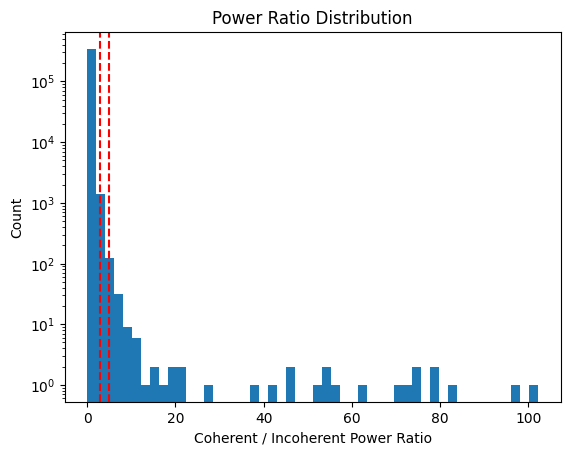

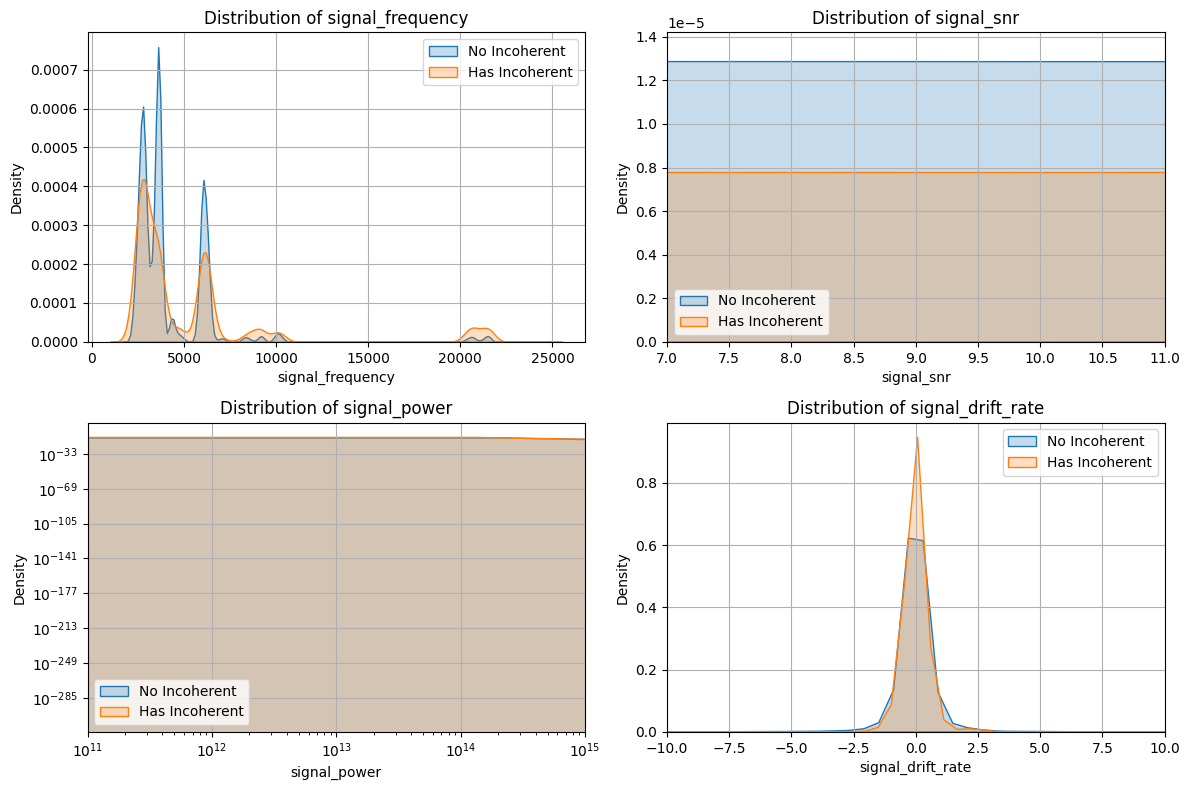

In [24]:
def power_ratio_calc(df):
    """  
    Calculating power ratios between matched coherent and incoherent beams
    """
    plt.hist(matched_df['power_ratio'], bins=50)
    plt.yscale('log')
    plt.axvline(3, color='r', linestyle='--')
    plt.axvline(5, color='r', linestyle='--')
    plt.xlabel('Coherent / Incoherent Power Ratio')
    plt.ylabel('Count')
    plt.title('Power Ratio Distribution')   
    plt.show()

power_ratio_calc(matched_df)


def power_ratio_vis(df_unmatched, df_matched):

    """  
    Evaluating and visualizing the power ratios between coherent and incoherent beams
    """
    no_incoh_df = df_unmatched
    has_incoh_df = df_matched

    features = ['signal_frequency', 'signal_snr', 'signal_power', 'signal_drift_rate']

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for i, col in enumerate(features):
        # Plot KDEs on each subplot
        sns.kdeplot(no_incoh_df[col].dropna(), label='No Incoherent', fill=True, ax=axes[i])
        sns.kdeplot(has_incoh_df[col].dropna(), label='Has Incoherent', fill=True, ax=axes[i])
        
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Density')
        axes[i].legend()
        axes[i].grid(True)
        
        if col == 'signal_snr':
            axes[i].set_xlim(7, 11)
        elif col == 'signal_power':
            axes[i].set_xscale('log')
            axes[i].set_xlim(1e11, 1e15)
            axes[i].set_yscale('log')
        elif col == 'signal_drift_rate':
            axes[i].set_xlim(-10, 10)

    plt.tight_layout()
    plt.show()

power_ratio_vis(unmatched_coh, matched_df)

In [25]:
def load_in_meerkat(file_name):
    """  
    Loading in MeerKAT data and adding configuration label
    """
    gaia_df= pd.read_pickle(f'/datax/scratch/ellambishop/meerkat_hits/{file_name}')

    df = gaia_df.copy() 
    df['config'] = 'MeerKAT'
    return df
    
#gaia_df = load_in_meerkat('meerkat_gaia.pkl')
gaia_df = load_in_meerkat('meerkat_named.pkl')

gaia_df

,file_uri,source_name,beam_id,ra_hours,dec_degrees,tstart,signal_frequency,signal_beam,signal_drift_rate,signal_snr,signal_power,signal_incoherent_power,signal_num_timesteps,filterbank_tsamp,observation_id,is_gaia,obs_base,matched_stamp_uris,num_matches,config
0,None,J0042+1246,0,10.679417,12.782667,60578.955519,849.996627,0,0.211866,42.040951,9.885755e+15,0.0,36,7.89516,guppi_60578_82556_000102_J0042+1246_0001.hits,False,guppi_60578_82556_000102_J0042+1246_0001,[guppi_60578_82556_000102_J0042+1246_0001.stam...,81,MeerKAT
1,None,J0042+1246,0,10.679417,12.782667,60578.971005,849.996899,0,0.171122,49.942707,1.158138e+16,0.0,36,7.89516,guppi_60578_83894_000108_J0042+1246_0001.hits,False,guppi_60578_83894_000108_J0042+1246_0001,[guppi_60578_83894_000108_J0042+1246_0001.stam...,83,MeerKAT
2,None,J0042+1246,0,10.679417,12.782667,60578.971005,863.985656,0,-0.008149,9.936605,3.052151e+15,0.0,36,7.89516,guppi_60578_83894_000108_J0042+1246_0001.hits,False,guppi_60578_83894_000108_J0042+1246_0001,[guppi_60578_83894_000108_J0042+1246_0001.stam...,83,MeerKAT
3,None,J0042+1246,0,10.679417,12.782667,60579.001989,863.985632,0,-0.004074,13.607316,3.812094e+15,0.0,36,7.89516,guppi_60579_00171_000118_J0042+1246_0001.hits,False,guppi_60579_00171_000118_J0042+1246_0001,[guppi_60579_00171_000118_J0042+1246_0001.stam...,89,MeerKAT
4,None,J0042+1246,0,10.679417,12.782667,60579.001989,863.998788,0,-0.018335,12.275190,3.532375e+15,0.0,36,7.89516,guppi_60579_00171_000118_J0042+1246_0001.hits,False,guppi_60579_00171_000118_J0042+1246_0001,[guppi_60579_00171_000118_J0042+1246_0001.stam...,89,MeerKAT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
764,None,J0042+1246,0,10.679417,12.782667,60579.001989,815.998855,0,-0.010186,7.717272,2.746502e+15,0.0,36,7.89516,guppi_60579_00171_000118_J0042+1246_0001.hits,False,guppi_60579_00171_000118_J0042+1246_0001,[guppi_60579_00171_000118_J0042+1246_0001.stam...,89,MeerKAT
765,None,J0042+1246,0,10.679417,12.782667,60578.955519,839.974576,0,-0.050929,11.210198,3.392704e+15,0.0,36,7.89516,guppi_60578_82556_000102_J0042+1246_0001.hits,False,guppi_60578_82556_000102_J0042+1246_0001,[guppi_60578_82556_000102_J0042+1246_0001.stam...,81,MeerKAT
766,None,J0042+1246,0,10.679417,12.782667,60578.955519,839.986078,0,-0.020372,38.151421,9.125829e+15,0.0,36,7.89516,guppi_60578_82556_000102_J0042+1246_0001.hits,False,guppi_60578_82556_000102_J0042+1246_0001,[guppi_60578_82556_000102_J0042+1246_0001.stam...,81,MeerKAT
767,None,J0042+1246,0,10.679417,12.782667,60578.955519,840.001540,0,-0.118156,45.904922,1.080400e+16,0.0,36,7.89516,guppi_60578_82556_000102_J0042+1246_0001.hits,False,guppi_60578_82556_000102_J0042+1246_0001,[guppi_60578_82556_000102_J0042+1246_0001.stam...,81,MeerKAT


In [26]:
def add_vla_config(df):
    """  
    Adds VLA configuration (config), date, and number of antennas to a dataframe based on tstart (MJD).
    Expects df to contain a column 'tstart' in MJD format.
    """

    # --- Extended VLA configuration date ranges ---
    vla_config_ranges = [
        (datetime.date(2023, 1, 19), datetime.date(2023, 5, 29), 'B'),
        (datetime.date(2023, 6, 2),  datetime.date(2023, 6, 19), 'BnA'),
        (datetime.date(2023, 6, 30), datetime.date(2023, 10, 2), 'A'),
        (datetime.date(2023, 10, 3), datetime.date(2023, 10, 19), 'A'),
        (datetime.date(2023, 10, 20), datetime.date(2024, 1, 15), 'D'),
        (datetime.date(2024, 1, 16), datetime.date(2024, 1, 24), 'D'),   # patch
        (datetime.date(2024, 1, 25), datetime.date(2024, 5, 7), 'C'),
        (datetime.date(2024, 5, 8),  datetime.date(2024, 9, 16), 'B'),
        (datetime.date(2024, 9, 17), datetime.date(2024, 10, 7), 'BnA'),
        (datetime.date(2024, 10, 8), datetime.date(2025, 2, 3), 'A'),
        (datetime.date(2025, 2, 4), datetime.date(2025, 2, 24), 'A'),     # new patch
        (datetime.date(2025, 2, 25), datetime.date(2025, 5, 12), 'D'),
        (datetime.date(2025, 5, 13), datetime.date(2025, 5, 21), 'C'),    # patch
        (datetime.date(2025, 5, 22), datetime.date(2025, 8, 18), 'C'),
        (datetime.date(2025, 8, 19), datetime.date(2025, 9, 2), 'B'),     # patch
        (datetime.date(2025, 9, 3),  datetime.date(2026, 1, 20), 'B'),
    ]


    # Config → number of antennas (nominal value = 27)
    config_to_n_antennas = {
        'A': 27,
        'B': 27,
        'C': 27,
        'D': 27,
        'BnA': 27,
        'CnB': 27,
        'Unknown': np.nan
    }

    # Initialize new columns
    dates, configs, n_antennas_list = [], [], []

    for t in df['tstart']:
        try:
            time = Time(t, format='mjd')
            date_str = time.to_value('iso', subfmt='date')
            date_obj = datetime.datetime.strptime(date_str, "%Y-%m-%d").date()
            dates.append(date_str)

            matched_config = 'Unknown'
            for start, end, cfg in vla_config_ranges:
                if start <= date_obj <= end:
                    matched_config = cfg
                    break
            configs.append(matched_config)
            n_antennas_list.append(config_to_n_antennas.get(matched_config, np.nan))

        except Exception as e:
            print(f"[!] Error parsing tstart={t}: {e}")
            dates.append('Invalid')
            configs.append('Unknown')
            n_antennas_list.append(np.nan)

    # Update dataframe
    df = df.copy()
    df['date'] = dates
    df['config'] = configs
    df['n_antennas'] = n_antennas_list

    return df


full_df = add_vla_config(full_df)
print(full_df['config'].value_counts())
print(full_df[['config', 'n_antennas']].drop_duplicates())

unmatched_coh = add_vla_config(unmatched_coh)
print(unmatched_coh['config'].value_counts())
print(unmatched_coh[['config', 'n_antennas']].drop_duplicates())


config
D      171401
A      114164
B       46291
C       11861
BnA       808
Name: count, dtype: int64
     config  n_antennas
0         A          27
1         D          27
13        B          27
66        C          27
1390    BnA          27
config
D      685364
A      631344
B      206966
C       64758
BnA      9819
Name: count, dtype: int64
       config  n_antennas
1           D          27
59795       C          27
181460      A          27
248018      B          27
393212    BnA          27


In [27]:
def assign_beam_size_arcsec(df):
    """   
    Calculates and assign the size of the beam for each hit depending on configuration
    """
    import numpy as np

    # Beam size per band and configuration (arcsec)
    beam_resolutions = {
        'P' : {'MeerKAT': 13},
        'L':  {'MeerKAT': 13}, 
        'S':  {'D': 23, 'C': 7.0, 'B': 2.1, 'A': 0.65},
        'C':  {'D': 12, 'C': 3.5, 'B': 1.0, 'A': 0.33},
        'X':  {'D': 7.2, 'C': 2.1, 'B': 0.6, 'A': 0.20},
    }

    conditions = [
        (df['signal_frequency'] >= 0)   & (df['signal_frequency'] < 850),
        (df['signal_frequency'] >= 850)  & (df['signal_frequency'] < 1800),
        (df['signal_frequency'] >= 2000) & (df['signal_frequency'] < 4000),
        (df['signal_frequency'] >= 4000) & (df['signal_frequency'] < 8000),
        (df['signal_frequency'] >= 8000) & (df['signal_frequency'] < 12000),
    ]
    band_labels = ['P', 'L', 'S', 'C', 'X']
    
    df = df.copy()
    df['band'] = np.select(conditions, band_labels, default='Unknown')

    # Default config if not present
    if 'config' not in df.columns:
        df['config'] = 'MeerKAT'

    beam_lookup = {
        (band, cfg): size
        for band, cfgs in beam_resolutions.items()
        for cfg, size in cfgs.items()
    }

    df['beam_key'] = list(zip(df['band'], df['config']))
    df['beam_size_arcsec'] = df['beam_key'].map(beam_lookup)

    return df


#VLA hits 
full_df= assign_beam_size_arcsec(full_df)
unmatched_coh = assign_beam_size_arcsec(unmatched_coh)

#MeerKAT hits
gaia_df = assign_beam_size_arcsec(gaia_df)

In [28]:
def flag_local_rfi(df, field, area_multiplier=3,
                   beam_threshold_fraction=0.75, drift_tol=1.0, beam_col='signal_beam',
                    frequency_tol=1.0, freq_col='signal_frequency', min_beams_floor =3):
    
    """ 
    Vectorized form of flag overlapping signals that have the same file URI/FOV but are in 
    spacially separated beams as potential RFI 
    """

    df = df.copy()
    df['freq_bin'] = (df[freq_col] / frequency_tol).round().astype(int)
    df['drift_bin'] = (df['signal_drift_rate'] / drift_tol).round().astype(int)
    df['rfi_flag_local'] = False
    df['drift_bin'] = (df['signal_drift_rate'] / drift_tol).round().astype(int)
    local_flag_count = 0

    beam_count_by_fov = df.groupby(field)['signal_beam'].nunique().to_dict()
    dec_mean_by_fov = df.groupby(field)['dec_degrees'].mean().to_dict()

    for fov, fov_group in df.groupby(field):
        total_beams = beam_count_by_fov.get(fov, 0)
        min_required_beams = max(3, int(beam_threshold_fraction * total_beams))
        dec0 = dec_mean_by_fov[fov]
        cos_dec = np.cos(np.deg2rad(dec0))
        avg_beam_size = fov_group['beam_size_arcsec'].mean()
        beam_area = np.pi * (avg_beam_size / 2) ** 2
        threshold_area = area_multiplier * beam_area

        for (freq, drift_bin), combo in fov_group.groupby(
                ['signal_frequency', 'drift_bin']):
            if combo['signal_beam'].nunique() < min_required_beams or len(combo) < 3:
                continue

            ra0 = combo['ra_hours'].mean()
            ra_off = (combo['ra_hours'] - ra0) * 3600 * cos_dec
            dec_off = (combo['dec_degrees'] - dec0) * 3600
            points = np.vstack([ra_off, dec_off]).T

            try:
                hull = ConvexHull(points)
                hit_area = hull.area
            except Exception:
                hit_area = 0

            if hit_area > threshold_area:
                df.loc[combo.index, 'rfi_flag_local'] = True
                local_flag_count += len(combo)

    return df, local_flag_count

In [29]:
def flag_temporal_persistence_rfi_fast(
    df,
    frequency_tol=1.0,       
    drift_tol=1.0,            
    radius_arcsec=None,       
    radius_multiplier=3,      
    min_time_gap_sec=10,      
    min_repeat_count=2,   
):
    """
    Vectorized replacement for flag_temporal_persistence_rfi.
 
    Flags signals whose (freq_bin, drift_bin) appears at the same sky position
    across multiple observations separated by at least min_time_gap_sec seconds.

    """
    
    df = df.copy()
    df["rfi_flag_global"] = False
 
    df["freq_bin"] = (df["signal_frequency"] / frequency_tol).round().astype(int)
    df["drift_bin"] = (df["signal_drift_rate"] / drift_tol).round().astype(int)
 
    # sky coords in arcsec (flat-sky approximation, good for small FOV) 
    dec_mean = df["dec_degrees"].mean()
    df["_ra_arcsec"] = df["ra_hours"] * 3600.0 * np.cos(np.deg2rad(dec_mean))
    df["_dec_arcsec"] = df["dec_degrees"] * 3600.0
 
    df["_tstart_sec"] = df["tstart"] * 86400.0  # MJD days → seconds
 
    if radius_arcsec is not None:
        df["_radius"] = float(radius_arcsec)
    else:
        df["_radius"] = radius_multiplier * df["beam_size_arcsec"].fillna(13.0)
 
    flagged_indices = set()
 
    grouped = df.groupby(["freq_bin", "drift_bin"])
 
    for (fb, db), grp in grouped:
        if len(grp) < min_repeat_count:
            continue
 
        ra = grp["_ra_arcsec"].values
        dec = grp["_dec_arcsec"].values
        t = grp["_tstart_sec"].values
        r = grp["_radius"].values
        idx = grp.index.values  
 
        n = len(grp)
 
        ra_diff = ra[:, None] - ra[None, :]       
        dec_diff = dec[:, None] - dec[None, :]
        dist = np.sqrt(ra_diff**2 + dec_diff**2)
 
        t_diff = np.abs(t[:, None] - t[None, :])  # seconds
 
        # radius threshold: use the larger of the two radii in each pair
        r_thresh = np.maximum(r[:, None], r[None, :])
 
        # valid neighbour: spatially close AND temporally separated
        valid = (dist <= r_thresh) & (t_diff >= min_time_gap_sec)
        np.fill_diagonal(valid, False)
 
        repeat_counts = valid.sum(axis=1)
 
        flag_mask = repeat_counts >= (min_repeat_count - 1)
        if flag_mask.any():
            flagged_indices.update(idx[flag_mask].tolist())
 
    df.loc[list(flagged_indices), "rfi_flag_global"] = True
 
    df = df.drop(columns=["_ra_arcsec", "_dec_arcsec", "_tstart_sec", "_radius"],
                 errors="ignore")
 
    return df, len(flagged_indices)

In [30]:

def flag_global_freq_repeats(df, freq_col='signal_frequency', drift_col='signal_drift_rate', 
                              time_col='tstart', obs_col = 'observation_id', flag_col='rfi_flag_global'):
    
    """ 
    Flags frequency–drift combinations that appear across multiple observations (FOVs),
    identifying globally recurring signals that are likely persistent interference or RFI.
    """
    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        print("[!] Skipping: DataFrame is None or empty.")
        return df

    if 'flag_strength' not in df.columns:
        df['flag_strength'] = 0

    repeat_groups = df.groupby([freq_col, drift_col])[obs_col].nunique()
    suspect_freqs = repeat_groups[repeat_groups > 1].index

    df['global_freq_repeat'] = df.set_index([freq_col, drift_col]).index.isin(suspect_freqs)

    # Sets flag and increments strength only for newly caught signals
    df.loc[df['global_freq_repeat'], flag_col] = True
    df.loc[df['global_freq_repeat'], 'flag_strength'] += 1

    print(f"Temporal persistence global RFI flagged: {df[flag_col].sum()}")
    print(f"Multi-FOV freq+drift repeats flagged: {df['global_freq_repeat'].sum()}")

    return df

In [31]:
def add_beam_count_flag(df, field):
    """
    Adds how many beams each signal frequency appears in per FOV,
    and a categorical beam_group column replacing the old df splits.
    """
    beam_counts = (
        df.groupby([field, 'signal_frequency'])['signal_beam']
        .nunique()
        .rename('n_beams_detected')
        .reset_index()
    )
    df = df.merge(beam_counts, on=[field, 'signal_frequency'], how='left')
    
    df['beam_group'] = pd.cut(
        df['n_beams_detected'],
        bins=[0, 2, 5, np.inf],
        labels=['1-2 beams', '3-5 beams', '6+ beams']
    )
    return df

def safe_mjd_to_datetime(mjd_series, min_mjd=40000, max_mjd=80000):
    # Coerce non-numeric values to NaN
    mjd_series = pd.to_numeric(mjd_series, errors='coerce')
    
    # Only keep plausible MJDs
    valid_mask = (mjd_series >= min_mjd) & (mjd_series <= max_mjd)
    
    out = pd.Series(pd.NaT, index=mjd_series.index)
    if valid_mask.any():
        out.loc[valid_mask] = Time(mjd_series.loc[valid_mask], format='mjd').to_datetime()
    return out

In [32]:
INSTRUMENT_CONFIGS = {
    'vla': {
        'field': 'file_uri',
        'beam_threshold_fraction': 0.5,
        'min_beams_floor': 2,
        'min_time_gap_sec': 600,
        'min_unique_tstarts': 20,
        'frequency_tol': 0.001,  # 1 kHz — comfortably above 5 Hz resolution
        'drift_tol': 1.0,
        'min_repeat_count': 3

    },
    'meerkat': {
        'field': 'observation_id',
        'beam_threshold_fraction': 0.5,
        'min_beams_floor': 2,
        'min_time_gap_sec': 0.3,   
        'min_unique_tstarts': 5,
        'frequency_tol': 0.001,  # same 1 kHz window as VLA
        'drift_tol': 1.0,
        'min_repeat_count' : 2
    },
}

def call_func(df, title, instrument='vla'):
    if not isinstance(df, pd.DataFrame) or df.empty:
        print(f"{title} is missing or empty; skipping.")
        return 0, 0, df

    print(f"Processing {title} ({len(df):,} hits)...")

    cfg = INSTRUMENT_CONFIGS[instrument]
    field = cfg['field']
    print(f"[i] Instrument: {instrument.upper()} | field: {field}")

    df['tstart_datetime'] = safe_mjd_to_datetime(df['tstart'])
    df['rfi_flag_global'] = False
    df['rfi_flag_local']  = False
    df['flag_strength']   = 0

    # Stage 1: local
    df, local_count = flag_local_rfi(
        df, field,
        beam_threshold_fraction=cfg['beam_threshold_fraction'],
        min_beams_floor=cfg['min_beams_floor'],
    )
    df.loc[df['rfi_flag_local'], 'flag_strength'] += 1
    print(f"[1] Local flags:    {local_count}")

    # Stage 2: temporal
    n_tstarts = df['tstart'].nunique()
    if n_tstarts < cfg['min_unique_tstarts']:
        print(f"[2] Temporal skipped — only {n_tstarts} unique tstarts")
        global_count = 0
    else:
        df = df.sort_values('tstart').reset_index(drop=True)
        df, global_count = flag_temporal_persistence_rfi_fast(
            df, min_time_gap_sec=cfg['min_time_gap_sec'], 
            frequency_tol=cfg['frequency_tol'],  # is this line actually there?
            drift_tol=cfg['drift_tol'],
            min_repeat_count= cfg['min_repeat_count']
        )
        df.loc[df['rfi_flag_global'], 'flag_strength'] += 1
        print(f"[2] Temporal flags: {global_count}")

    # Stage 3: global freq repeats
    df = flag_global_freq_repeats(df,obs_col='observation_id')
    print(f"[3] Global flags:   {df['global_freq_repeat'].sum()}")

    df = add_beam_count_flag(df, field)
    print(f"\nBeam group distribution:\n{df['beam_group'].value_counts()}")
    print(f"Flag strength distribution:\n{df['flag_strength'].value_counts().sort_index()}")

    return local_count, global_count, df

In [35]:
#VLA data 
print("VLA matched hit analysis")
print("------------------------")
local_count, global_count, df_vla = call_func(full_df,     'VLA hits',  instrument='vla')

print("\n VLA unmatched hits analysis")
print("------------------------")
local_count_unmatched, global_count_unmatched, df_vla_unmatched = call_func(unmatched_coh,'VLA hits unmatched',  instrument='vla')

# #MeerKAT data 
print("\n MeerKAT hits analaysis")
print("------------------------")
local_count_meer, global_count_meer, df_meerkat  = call_func(gaia_df, 'MeerKAT hits', instrument='meerkat')


VLA matched hit analysis
------------------------
Processing VLA hits (344,525 hits)...
[i] Instrument: VLA | field: file_uri
[1] Local flags:    39
[2] Temporal flags: 117447
Temporal persistence global RFI flagged: 117447
Multi-FOV freq+drift repeats flagged: 0
[3] Global flags:   0

Beam group distribution:
beam_group
1-2 beams    344474
3-5 beams        51
6+ beams          0
Name: count, dtype: int64
Flag strength distribution:
flag_strength
0    227045
1    117474
2         6
Name: count, dtype: int64

 VLA unmatched hits analysis
------------------------
Processing VLA hits unmatched (1,598,251 hits)...
[i] Instrument: VLA | field: file_uri
[1] Local flags:    425161
[2] Temporal flags: 657000
Temporal persistence global RFI flagged: 784582
Multi-FOV freq+drift repeats flagged: 325701
[3] Global flags:   325701

Beam group distribution:
beam_group
1-2 beams    998749
3-5 beams    599502
6+ beams          0
Name: count, dtype: int64
Flag strength distribution:
flag_strength
0    

In [36]:
def compute_beam_occupancy(
    df,
    freq_tol=1.0,        
    drift_tol=0.5,       
    beam_col="beam_id",
    freq_col="signal_frequency",
    drift_col="signal_drift_rate",
    tstart_col="tstart",
    total_beams=64,
):
    """
    Compute beam occupancy fraction for each unique signal group. Mainly useful for MeerKAT
 
    For each (tstart, freq_bin, drift_bin) group, counts how many distinct
    beams contain that signal and divides by total_beams to get occupancy ∈ [0,1].
 
    A genuine technosignature should appear in exactly 1 beam (occupancy ≈ 1/64).
    RFI that couples into the receiver chain appears in all or most beams
    (occupancy → 1).
    """
    df = df.copy()
 
    df["_freq_bin"] = (df[freq_col] / freq_tol).round().astype(int)
    df["_drift_bin"] = (df[drift_col] / drift_tol).round().astype(int)
 
    # group per observation (tstart) so we don't conflate different obs epochs
    group_cols = [tstart_col, "_freq_bin", "_drift_bin"]
 
    beam_counts = (
        df.groupby(group_cols)[beam_col]
        .nunique()
        .reset_index()
        .rename(columns={beam_col: "n_beams_occupied"})
    )
    beam_counts["beam_occupancy"] = beam_counts["n_beams_occupied"] / total_beams
 
    # merge back onto original df
    df = df.merge(beam_counts[group_cols + ["n_beams_occupied", "beam_occupancy"]],
                  on=group_cols, how="left")
 
    df = df.drop(columns=["_freq_bin", "_drift_bin"], errors="ignore")
 
    # summary table — one row per group
    occupancy_summary = beam_counts.copy()
    occupancy_summary["beam_occupancy_pct"] = (
        occupancy_summary["beam_occupancy"] * 100
    ).round(1)
 
    return df, occupancy_summary
 
 
def label_beam_occupancy_rfi(
    df,
    single_beam_thresh=0.05,   # ≤ 5 % of beams → candidate
    rfi_thresh=0.75,            # ≥ 75 % of beams → strong RFI 
    occupancy_col="beam_occupancy",
):
    """
    Add a categorical 'occupancy_label' column based on beam occupancy fraction.
    """
    df = df.copy()
 
    if occupancy_col not in df.columns:
        raise ValueError(
            f"Column '{occupancy_col}' not found. Run compute_beam_occupancy first."
        )
 
    conditions = [
        df[occupancy_col] <= single_beam_thresh,
        df[occupancy_col] >= rfi_thresh,
    ]
    choices = ["candidate", "rfi"]
    df["occupancy_label"] = np.select(conditions, choices, default="maybe_rfi")
 
    if "flag_strength" not in df.columns:
        df["flag_strength"] = 0
 
    df.loc[df["occupancy_label"] == "maybe_rfi", "flag_strength"] += 1
    df.loc[df["occupancy_label"] == "rfi", "flag_strength"] += 2
 
    return df

In [37]:
""" Calling analysis functions physical properties to add to flagging properties """

df_meerkat, occ_summary = compute_beam_occupancy(df_meerkat)
df_meerkat = label_beam_occupancy_rfi(df_meerkat)

df_vla, occ_summary_vla = compute_beam_occupancy(df_vla)
df_vla= label_beam_occupancy_rfi(df_vla)

df_vla_unmatched, occ_summary_vla_unmatched = compute_beam_occupancy(df_vla_unmatched)
df_vla_unmatched = label_beam_occupancy_rfi(df_vla_unmatched)

In [ ]:
"""
Main plotting evalutation for beam analysis with MeerKAT and VLA
"""

def plot_panel_1(df, total_beams=64, ax=None):
    """
    Plot histogram of beam occupancy fraction with reference lines.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,4))

    occ = df["beam_occupancy"].dropna()
    n_beams = (occ * total_beams).round().astype(int)

    bins = np.arange(0, total_beams + 2) - 0.5

    ax.hist(
        n_beams,
        bins=bins,
        color="steelblue",
        edgecolor="white",
        linewidth=0.5
    )

    ax.axvline(
        1,
        linestyle="--",
        color="green",
        label="Single-beam expectation"
    )

    ax.axvline(
        total_beams * 0.75,
        linestyle="--",
        color="red",
        label="RFI regime"
    )

    ax.set_yscale("log")
    ax.set_xlabel("Number of beams occupied")
    ax.set_ylabel("Count")
    ax.set_title("Beam Occupancy Distribution")
    ax.legend()

    return ax

def plot_panel_2(df):
    fig, ax = plt.subplots(figsize=(6,4))

    ax.scatter(
        df["beam_occupancy"],
        df["flag_strength"],
        s=2,
        alpha=0.25
    )

    ax.set_yscale("log")
    ax.set_xlabel("Beam occupancy (fraction)")
    ax.set_ylabel("RFI flag strength")
    ax.set_title("RFI strength vs beam occupancy")

    plt.tight_layout()
    return fig

def plot_panel_3(df):
    fig, ax = plt.subplots(figsize=(6,4))

    order = ["candidate", "maybe_rfi", "rfi"]

    data = [
        df[df["occupancy_label"] == lab]["flag_strength"]
        for lab in order
    ]

    ax.boxplot(data, labels=order, showfliers=False)

    ax.set_yscale("log")
    ax.set_ylabel("RFI flag strength")
    ax.set_title("RFI strength by occupancy class")

    plt.tight_layout()
    return fig

def call_plotting(df):
    fig1 = plot_panel_1(df)
    fig2 = plot_panel_2(df)
    fig3 = plot_panel_3(df)
    return plt.show()


/tmp/ipykernel_201469/1248296082.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, showfliers=False)
/tmp/ipykernel_201469/1248296082.py:75: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale("log")


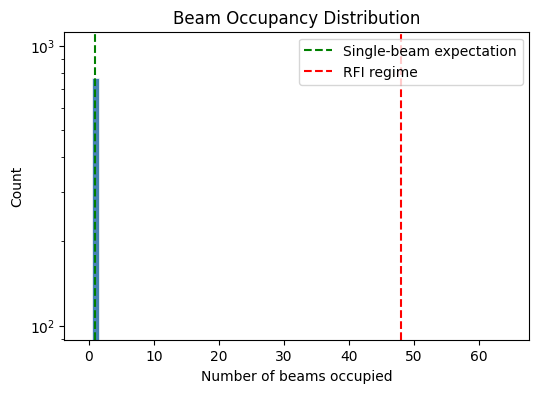

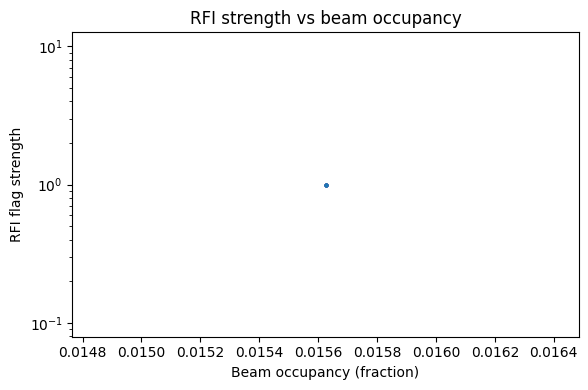

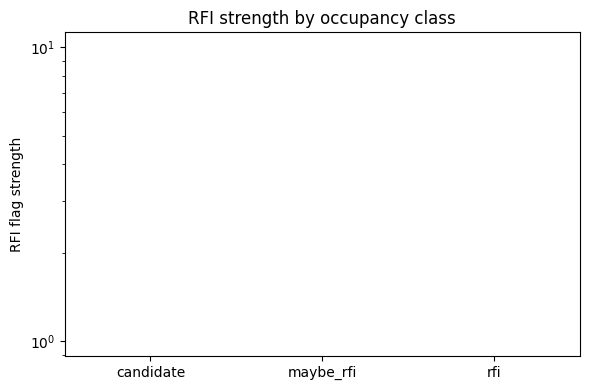

In [39]:
call_plotting(df_meerkat)

/tmp/ipykernel_201469/1248296082.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, showfliers=False)


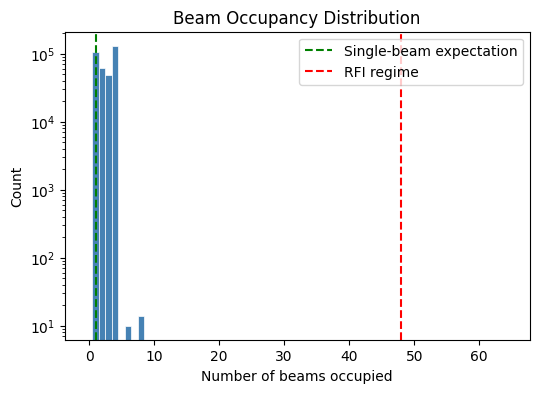

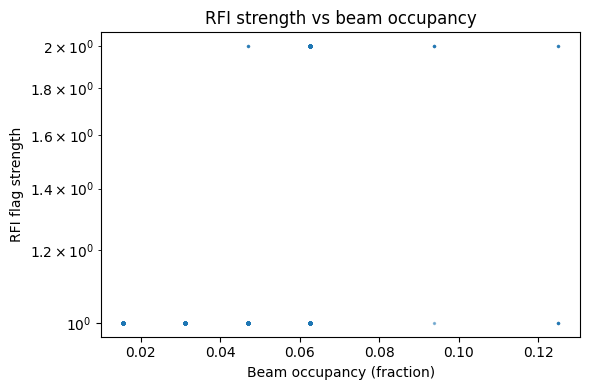

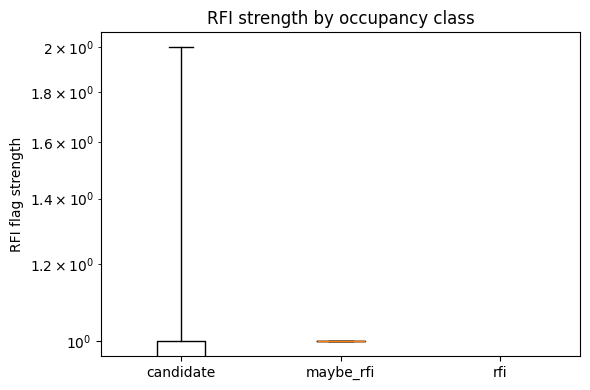

In [40]:
call_plotting(df_vla)

/tmp/ipykernel_201469/1248296082.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, showfliers=False)


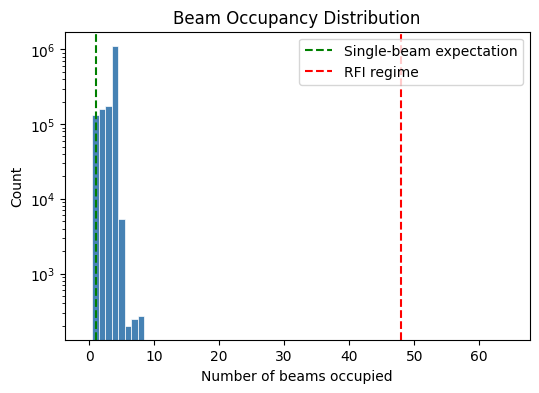

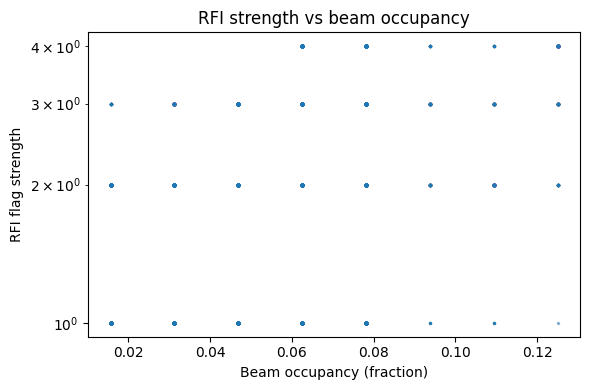

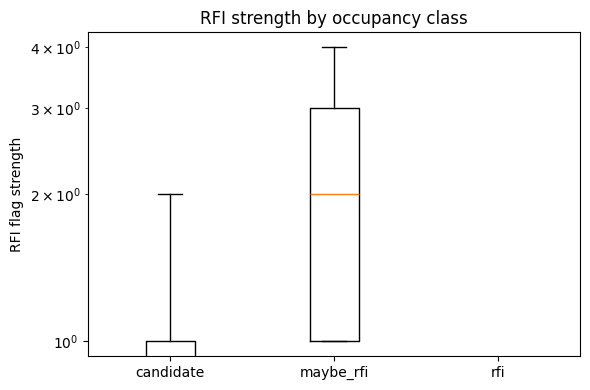

In [41]:
call_plotting(df_vla_unmatched)

In [45]:
#set all flags within the df 
def apply_rfi_flagging(df, local_count=None, global_count=None,
                       apply_spatial_flags=True,
                       apply_power_ratio_flag=True,
                       missing_power=True, 
                       unmatched = False,
                       debug=False) :
    if local_count is not None:
        print(f"Local RFI flagged:  {local_count}")
    if global_count is not None:
        print(f"Global RFI flagged: {global_count}")

    # Ensure required flag columns exist and are boolean
    required_bool_cols = [
        'rfi_flag_local', 'rfi_flag_global', 'global_freq_repeat',
        'freq_has_incoherent_counterpart', 'freq_has_phase_center_counterpart'
    ]
    for col in required_bool_cols:
        if col not in df.columns:
            df[col] = False
        df[col] = df[col].fillna(False).astype(bool)

    # Ensure power_ratio exists
    if 'power_ratio' not in df.columns:
        df['power_ratio'] = np.nan

    # Flag for missing power ratio
    df["rfi_flag_missing_power_ratio"] = df["power_ratio"].isna()

    # Initialize main flags
    df['rfi_flag'] = False
    df['rfi_flag'] = df['rfi_flag'].astype(bool)
    df['flag_strength'] = 0

    stage_counts = {}
    stage_counts['initial'] = len(df)

    # --- Spatial flags ---
    if apply_spatial_flags:
        # Local flag
        df.loc[df['rfi_flag_local'], 'rfi_flag'] = True
        df.loc[df['rfi_flag_local'], 'flag_strength'] += 1
        stage_counts['after_local_flag'] = (~df['rfi_flag']).sum()

        # Global only (global but not local)
        global_only = df['rfi_flag_global'] & (~df['rfi_flag_local'])
        df.loc[global_only, 'rfi_flag'] = True
        df.loc[global_only, 'flag_strength'] += 1
        stage_counts['after_global_only_flag'] = (~df['rfi_flag']).sum()

    # --- Power ratio flags ---
    if apply_power_ratio_flag:
        cond_power = df['power_ratio'].notna() & ((df['power_ratio'] < 3) | (df['power_ratio'] > 5))
        df.loc[cond_power, 'rfi_flag'] = True
        df.loc[cond_power, 'flag_strength'] += 2
        stage_counts['after_cond2'] = (~df['rfi_flag']).sum()

    # --- Global repeat flags ---
    df['global_freq_repeat'] = df['global_freq_repeat'].fillna(False).astype(bool)
    df.loc[df['global_freq_repeat'], 'rfi_flag'] = True
    df.loc[df['global_freq_repeat'], 'flag_strength'] += 1
    stage_counts['after_global_repeat'] = (~df['rfi_flag']).sum()

    # --- Missing power ratio flags ---
    if missing_power:
        df.loc[df['rfi_flag_missing_power_ratio'], 'rfi_flag'] = True
        df.loc[df['rfi_flag_missing_power_ratio'], 'flag_strength'] += 1
        stage_counts['after_missing_power_ratio'] = (~df['rfi_flag']).sum()

    if unmatched:
        cond_unmatched_mask = df['signal_snr'] < 50
        df.loc[cond_unmatched_mask, 'rfi_flag'] = True
        df.loc[cond_unmatched_mask, 'flag_strength'] += 2
        stage_counts['after_unmatched_upper_threshold'] = (~df['rfi_flag']).sum()

    if debug:
        print("Counts for conditions:")
        print(f"cond2 (power ratio outside [3,5]): {cond_power.sum() if apply_power_ratio_flag else 0}")
        print(f"global_only (global but not local): {global_only.sum() if apply_spatial_flags else 0}")
        print(f"global_freq_repeat: {df['global_freq_repeat'].sum()}")
        print(f"Missing power ratio: {df['rfi_flag_missing_power_ratio'].sum()}")
        print("\n")

    return df, stage_counts


In [46]:
def process_and_split_rfi(
    df,
    local_count=None,
    global_count=None,
    gaia=True,
    unmatched=False,
    beam_group_col="beam_group",
    include_beam_info=True
):
    def split_by_flag_strength(df, clean_thresh=0, maybe_thresh=1):
        clean_df = df[df['flag_strength'] <= clean_thresh]
        maybe_rfi_df = df[(df['flag_strength'] > clean_thresh) & (df['flag_strength'] <= maybe_thresh)]
        strong_rfi_df = df[df['flag_strength'] > maybe_thresh]
        return clean_df, maybe_rfi_df, strong_rfi_df

    apply_power_ratio_flag = not gaia

    # ---- sanity checks ----
    if include_beam_info and beam_group_col not in df.columns:
        raise ValueError(f"Missing {beam_group_col}. Run add_beam_count_flag first.")

    # ---- single RFI pass on FULL dataset ----
    fin_df, stage_counts = apply_rfi_flagging(
        df,
        local_count=local_count,
        global_count=global_count,
        apply_spatial_flags=True,
        apply_power_ratio_flag=apply_power_ratio_flag,
        missing_power=apply_power_ratio_flag,
        unmatched=unmatched,
        debug=False,
    )

    # ---- split only by RFI strength ----
    clean_df, maybe_rfi_df, strong_rfi_df = split_by_flag_strength(fin_df)

    # ---- summary ----
    print("\n=== Summary ===")
    print(f"Clean:      {len(clean_df)}")
    print(f"Maybe RFI:  {len(maybe_rfi_df)}")
    print(f"Strong RFI: {len(strong_rfi_df)}")

    if len(fin_df) > 0:
        print(f"Clean %: {100 * len(clean_df) / len(fin_df):.2f}%")

    return clean_df, maybe_rfi_df, strong_rfi_df, stage_counts

In [48]:

clean_df, maybe_rfi_df, strong_rfi_df, combined_stage_counts = process_and_split_rfi(
    df_vla,
    local_count=local_count,
    global_count=global_count,
)

clean_unmatched_df, maybe_rfi_unmatched_df, strong_rfi_unmatched_df,combined_stage_counts_unmatched  = process_and_split_rfi(
    df_vla_unmatched,
    local_count=local_count_unmatched,
    global_count=global_count_unmatched,
     unmatched =True
)

    
clean_meer_df, maybe_rfi_meer_df, strong_rfi_meer_df, combined_stage_counts_meer = process_and_split_rfi(
    df_meerkat,
    local_count=local_count_meer,
    global_count=global_count_meer,
    gaia=True
)


Local RFI flagged:  39
Global RFI flagged: 117447

=== Summary ===
Clean:      227045
Maybe RFI:  117480
Strong RFI: 0
Clean %: 65.90%
Local RFI flagged:  425161
Global RFI flagged: 657000



=== Summary ===
Clean:      82555
Maybe RFI:  163676
Strong RFI: 1352020
Clean %: 5.17%
Local RFI flagged:  0
Global RFI flagged: 171

=== Summary ===
Clean:      598
Maybe RFI:  171
Strong RFI: 0
Clean %: 77.76%


In [68]:
def plot_rfi_reduction_waterfall(stage_counts_dict, title="RFI Reduction Waterfall",
                                  save_path=None):
    """
    Bar chart showing hits remaining after each pipeline stage.
    """
    labels = list(stage_counts_dict.keys())
    counts = list(stage_counts_dict.values())
 
    colors = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(labels)))
 
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(labels, counts, color=colors, edgecolor="white", linewidth=0.5)
 
    # annotate count + % remaining vs. first stage
    initial = counts[0]
    for bar, count in zip(bars, counts):
        pct = 100 * count / initial
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.02,
            f"{count:,}\n({pct:.1f}%)",
            ha="center", va="bottom", fontsize=8
        )
 
    ax.set_yscale("log")
    ax.set_ylabel("Hits remaining (log scale)")
    ax.set_title(title, pad=25)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()


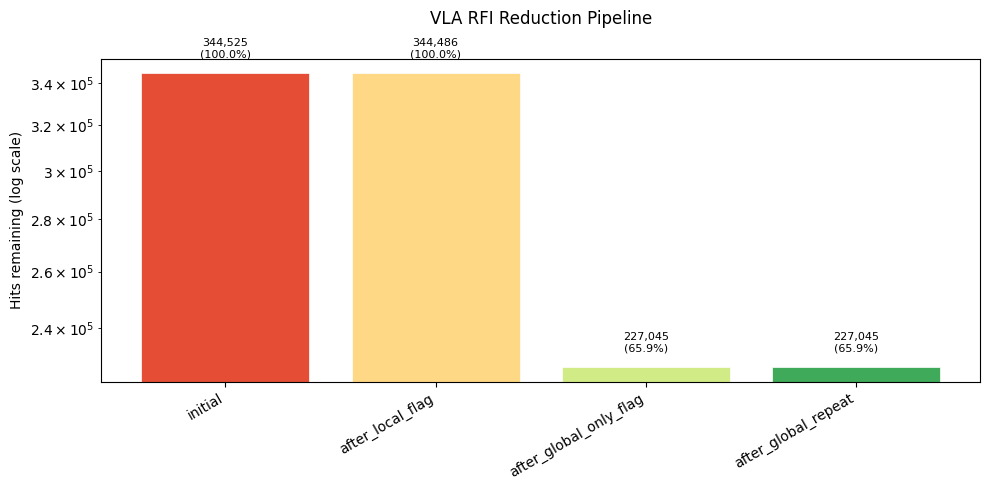

In [69]:
plot_rfi_reduction_waterfall(
    combined_stage_counts,
    title="VLA RFI Reduction Pipeline"
)

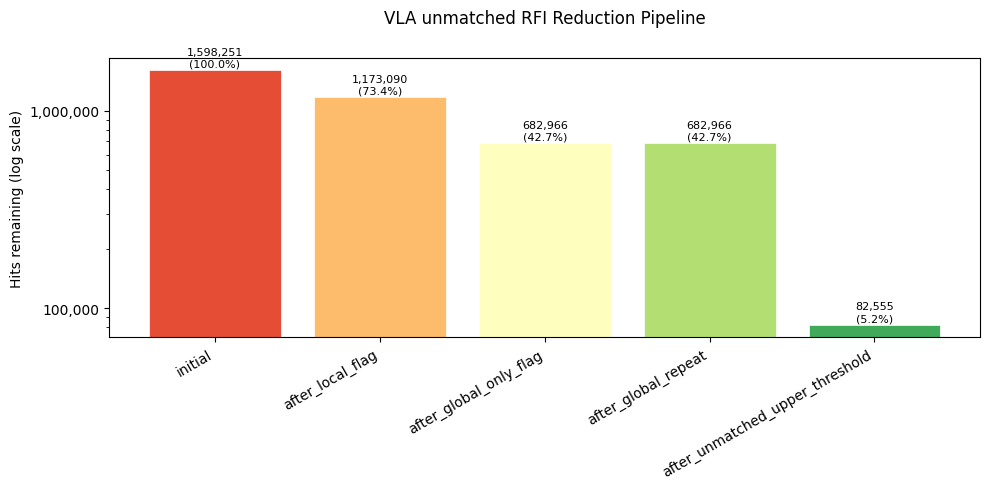

In [70]:
plot_rfi_reduction_waterfall(
    combined_stage_counts_unmatched,
    title="VLA unmatched RFI Reduction Pipeline"
)

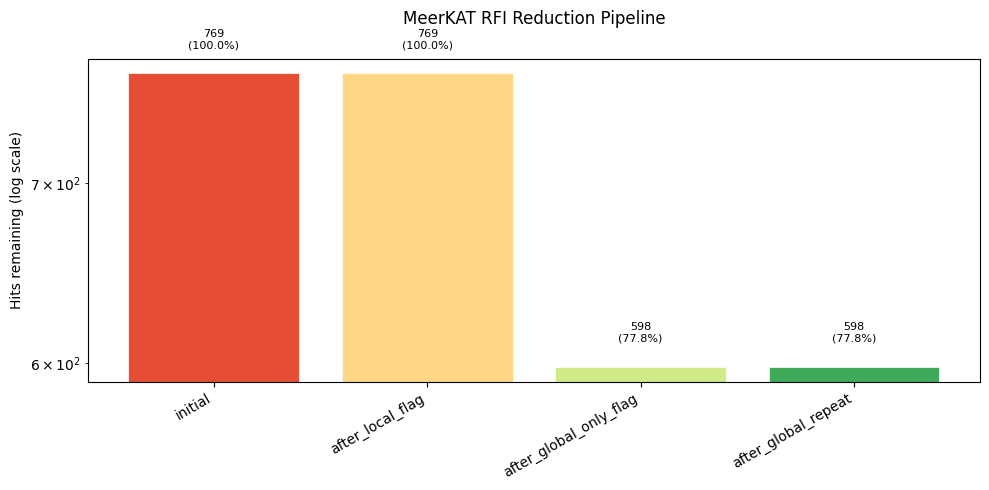

In [71]:
plot_rfi_reduction_waterfall(
    combined_stage_counts_meer,
    title="MeerKAT RFI Reduction Pipeline"
)

In [74]:

 # Saving output files for later visualization and analysis of candidate technosignatures 
os.makedirs('/datax/scratch/ellambishop/final_clean_data', exist_ok=True)
output_dir ="/datax/scratch/ellambishop/final_clean_data"

#Non-VLASS
filename_clean = "clean_non_vlass.pkl"
filename_maybe = "maybe_rfi_non_vlass.pkl"
filename_clean_unmatched = "clean_unmatched_non_vlass.pkl"
filename_maybe_unmatched = "maybe_rfi_unmatched_non_vlass.pkl"

#VLASS 
filename_clean_vlass = "clean_vlass.pkl"
filename_maybe_vlass = "maybe_rfi_vlass.pkl"
filename_clean_unmatched_vlass = "clean_unmatched_vlass.pkl"
filename_maybe_unmatched_vlass = "maybe_rfi_unmatched_vlass.pkl"

#MeerKAT
filename_clean_meer = "clean_MeerKAT.pkl"
filename_maybe_meer = "maybe_rfi_MeerKAT.pkl"

def append_to_pickle(file, data):
    filename = os.path.join(output_dir, file)

    if os.path.exists(filename):
        existing_df = pd.read_pickle(filename)
        combined_df = pd.concat([existing_df, data], ignore_index=True)
    else:
        combined_df = data

    combined_df.to_pickle(filename)


# Non-VLASS Hits

append_to_pickle(filename_clean, clean_df)
append_to_pickle(filename_maybe, maybe_rfi_df)

append_to_pickle(filename_clean_unmatched, clean_unmatched_df)
append_to_pickle(filename_maybe_unmatched, maybe_rfi_unmatched_df)

#VLASS Hits 

# append_to_pickle(filename_clean_vlass, clean_df)
# append_to_pickle(filename_maybe_vlass, maybe_rfi_df)

# append_to_pickle(filename_clean_unmatched_vlass, clean_unmatched_df)
# append_to_pickle(filename_maybe_unmatched_vlass, maybe_rfi_unmatched_df)

#MeerKAT Hits 

append_to_pickle(filename_clean_meer, clean_meer_df)
append_to_pickle(filename_maybe_meer, maybe_rfi_meer_df)